# Aviation Risk Analysis: Identifying Safer Aircraft Models for Purchase Recommendations



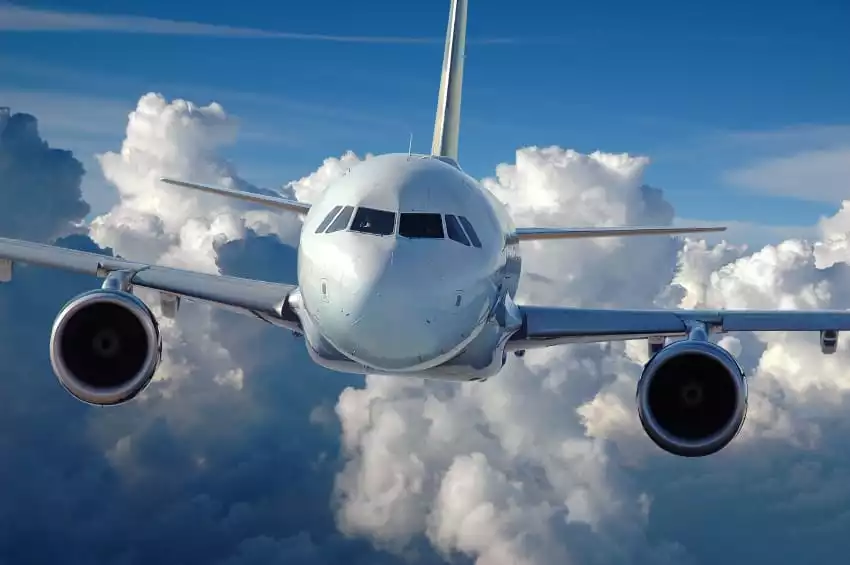

In [194]:
from IPython.display import Image
Image(filename="aero.jpg", width=500)

  
**Author:** Fredrick Ochieng




## 1. Overview

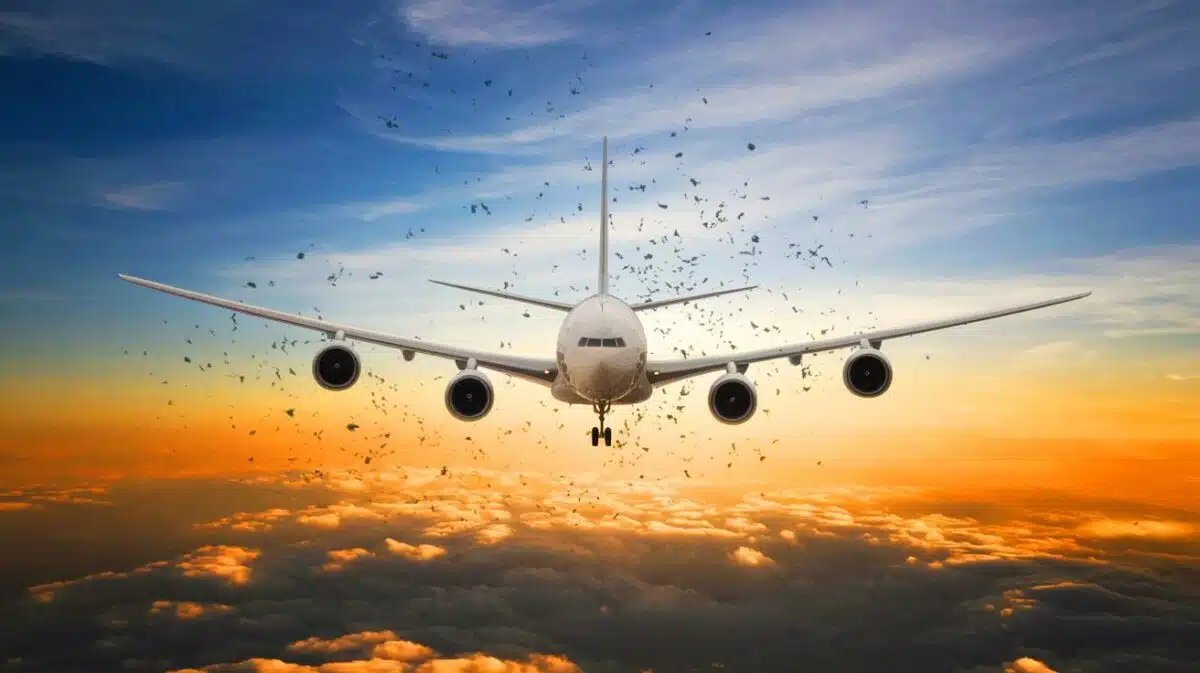

In [195]:
Image(filename="space-debris.jpg", width=500)

My company is exploring entry into the aviation industry.  
The leadership team needs to know which aircraft types present **lower risks**.  

**Goal:** Analyze aviation accident data to recommend safer aircraft models.  
**Dataset:** Aviation accidents data (1919–2023).   

## 2. Business Problem
My company is considering expanding into aviation and needs to assess which aircraft types/models pose the least risk. Entering this industry carries significant safety, financial, and reputational implications, so it is essential that decisions are guided by data rather than assumptions. By analyzing decades of accident records, this project addresses three key questions/objectives: 
1. Which aircraft models/types are safer?  
2.  What are the accident trends over time? 
3. Which operators and countries account for the most accidents? 

The answers to the above questions will provide leadership with actionable insights to guide purchase recommendations and inform ongoing risk management strategies.

## 3. Data Understanding
The dataset used in this project (`aviation-accident-data-2023-05-16.csv`) covers aviation accidents data from 1919 to 2023. The dataset includes a wide range of details for each recorded event.

Key features include:

**Date and Year**: When the accident occurred

**Aircraft Type**: The model or category of aircraft involved

**Operator**: The airline, company, or private owner

**Fatalities**: Number of lives lost 

**Location and Country**: Where the event occurred

**Other fields**: Registration numbers and coded accident categories

## 4. Data Loading and Inspection

In [196]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [197]:
#Loading the dataset into a datafram "df"
#Displaying the first five rows
df = pd.read_csv('aviation-accident-data-2023-05-16.csv')
df.head()

,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown


In [198]:
#Displaying the last five rows
df.tail()

,date,type,registration,operator,fatalities,location,country,cat,year
23962,11-MAY-2023,Hawker 900XP,PK-LRU,Angkasa Super Services,0,Maleo Airport (MOH),Indonesia,A2,2023
23963,11-MAY-2023,Cessna 208B Grand Caravan,PK-NGA,Nasional Global Aviasi,0,Fentheik Airstrip,Indonesia,A2,2023
23964,12-MAY-2023,Cessna 208B Grand Caravan,5X-RBR,Bar Aviation,0,Kampala-Kajjansi...,Uganda,A1,2023
23965,14-MAY-2023,Boeing 747-4R7F,LX-OCV,Cargolux,0,Luxembourg-Finde...,Luxembourg,A2,2023
23966,15-MAY-2023,Learjet 35A,D-CGFQ,GFD,2,Hohn Air Base,Germany,A1,2023


In [199]:
#Checking the shape of the dataset
df.shape

(23967, 9)

The dataset has 23,967 rows (records of different aviation accidents) and 9 columns (variables/particulars).

In [200]:
#Summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          23967 non-null  object
 1   type          23967 non-null  object
 2   registration  22419 non-null  object
 3   operator      23963 non-null  object
 4   fatalities    20029 non-null  object
 5   location      23019 non-null  object
 6   country       23967 non-null  object
 7   cat           23967 non-null  object
 8   year          23967 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


Some of the variables have missing values. These variables include registration, operator, fatalities, and location.

In [201]:
#Inspecting the datatypes of each column
df.dtypes

date            object
type            object
registration    object
operator        object
fatalities      object
location        object
country         object
cat             object
year            object
dtype: object

In [202]:
#Converting fatalities to numeric
df['fatalities'] = pd.to_numeric(df['fatalities'], errors='coerce')

In [203]:
#Converting year to numeric 
df['year'] = pd.to_numeric(df['year'], errors='coerce')

In [204]:
#Re-inspecting the datatypes of each column
df.dtypes

date             object
type             object
registration     object
operator         object
fatalities      float64
location         object
country          object
cat              object
year            float64
dtype: object

In [205]:
#Checking for duplicates
df.duplicated().value_counts()

False    23852
True       115
dtype: int64

There are duplicates in the dataset. These are dropped in the subsequet section (data cleaning)

## 5. Data Cleaning

The previous section shows that there are duplicates and missing values. Thus, in this section I will clean the data to facilitate subsequent analyses 

In [206]:
#Dropping duplicates
df = df.drop_duplicates()

In [207]:
#Rechecking for duplicates
df.duplicated().value_counts()

False    23852
dtype: int64

All duplicates have been dropped

In [208]:
#Checking for missing values (NaNs)
#isna().sum to check for total number of missing values per column
df.isna().sum()

date               0
type               0
registration    1434
operator           4
fatalities      4186
location         932
country            0
cat                0
year              61
dtype: int64

In [209]:
#Checking the missing values in terms of percentages
a = df.shape

nan_percent = (df.isna().sum() / a[0])*100 # total percent of missing values per column
nan_percent

date             0.000000
type             0.000000
registration     6.012074
operator         0.016770
fatalities      17.549891
location         3.907429
country          0.000000
cat              0.000000
year             0.255744
dtype: float64

As shown above, `fatalities` has the largest percentage of missing values (~17.5%). Given that this variable is important for the analysis, the missing values have to be replaced. The missing values for `operator` and `location` also have to be repalced since they are important for the analysis. The `registration` column can be dropped since its not important for the analysis (it doesn’t add value to model-level safety analysis). Further the rows with missing `year` will be dropped. 

In [210]:
#Dropping `registration` column
df.drop(['registration'], axis=1, inplace=True)
df.head()

,date,type,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,Indonesian AF,NaN,NaN,Unknown country,U1,NaN
1,date unk.,Antonov An-12B,Indonesian AF,NaN,NaN,Unknown country,U1,NaN
2,date unk.,Antonov An-12B,Indonesian AF,NaN,NaN,Unknown country,U1,NaN
3,date unk.,Antonov An-12BK,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,NaN
4,date unk.,Antonov An-12BP,Soviet AF,0.0,Massawa Airport ...,Eritrea,A1,NaN


In [211]:
#dropping rows with unkown years
df=df.dropna(subset=['year'])

In [212]:
#Making sure year is integer
df['year'] = df['year'].astype(int)

Handling missing values in `fatalities column`

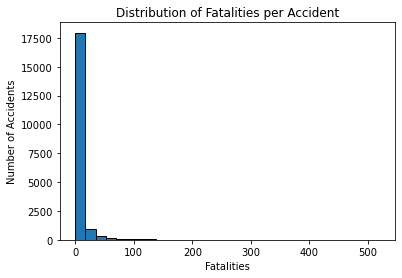

In [213]:
#Checking for skewness using histogram to determine whether to fill missing values using mean or median.
#If skewed use median else use mean
plt.hist(df['fatalities']. dropna(), bins=30, edgecolor='black')
plt.title('Distribution of Fatalities per Accident')
plt.xlabel('Fatalities')
plt.ylabel('Number of Accidents')
plt.show()

In [214]:
#The data is skewed (long-tailed) so the missing values should be filled using the median
median_fatalities = df['fatalities'].median()
print('Median fatalities:', median_fatalities) 

Median fatalities: 0.0


In [215]:
#Since most of the accidents have 0 deaths, the median comes out as 0.
#Therefore, median won't be helpful in filling the missing values. As such, mean is used. 
mean_fatalities = df['fatalities'].mean()
print('Mean fatalities:', mean_fatalities)

Mean fatalities: 6.146275647879436


In [216]:
#Filling missing values
df['fatalities'] = df['fatalities'].fillna(mean_fatalities)

Handling missing values in the `operator` column

In [217]:
#`operatior` indicates who owned/operated the aircraft. It's non-numeric and therefore the mode is used to fill the missing values
df['operator'].fillna(df['operator'].mode()[0], inplace=True)

Handling missing values in the `location` column

In [218]:
#Since the percentage of missing rows is small, dropping rows with missing values is a solid option for this variable.
df = df.dropna(subset=['location'])

In [219]:
#Creating a new clean dataframe after doing the data cleaning
df_clean = df.copy()

In [220]:
#Rechecking missing values
df_clean.isna().sum()

date          0
type          0
operator      0
fatalities    0
location      0
country       0
cat           0
year          0
dtype: int64

In [221]:
#Shape of the cleaned data
df_clean.shape

(22887, 8)

In [222]:
df_clean.head()

,date,type,operator,fatalities,location,country,cat,year
61,02-AUG-1919,Caproni Ca.48,Caproni,14.0,Verona,Italy,A1,1919
62,11-AUG-1919,Felixstowe Fury,RAF,1.0,near Felixtowe RNAS,U.K.,A1,1919
63,23-FEB-1920,Handley Page O/7,Handley Page Transport,0.0,"Acadia Siding, C...",South Africa,A1,1920
64,25-FEB-1920,Handley Page O/400,Handley Page Transport,0.0,near El Shereik,Sudan,A1,1920
65,30-JUN-1920,Handley Page O/400,Handley Page Transport,0.0,ÃstanÃ¥,Sweden,A1,1920


In [223]:
df_clean.tail()

,date,type,operator,fatalities,location,country,cat,year
23962,11-MAY-2023,Hawker 900XP,Angkasa Super Services,0.0,Maleo Airport (MOH),Indonesia,A2,2023
23963,11-MAY-2023,Cessna 208B Grand Caravan,Nasional Global Aviasi,0.0,Fentheik Airstrip,Indonesia,A2,2023
23964,12-MAY-2023,Cessna 208B Grand Caravan,Bar Aviation,0.0,Kampala-Kajjansi...,Uganda,A1,2023
23965,14-MAY-2023,Boeing 747-4R7F,Cargolux,0.0,Luxembourg-Finde...,Luxembourg,A2,2023
23966,15-MAY-2023,Learjet 35A,GFD,2.0,Hohn Air Base,Germany,A1,2023


In [224]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22887 entries, 61 to 23966
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        22887 non-null  object 
 1   type        22887 non-null  object 
 2   operator    22887 non-null  object 
 3   fatalities  22887 non-null  float64
 4   location    22887 non-null  object 
 5   country     22887 non-null  object 
 6   cat         22887 non-null  object 
 7   year        22887 non-null  int32  
dtypes: float64(1), int32(1), object(6)
memory usage: 1.5+ MB


The dataset is clean with 22,887 rows and 8 columns

In [225]:
#Creating a cleaned csv file
df_clean.to_csv("cleaned-aviation-accident-data-2023-05-16.csv", index=False)  

## 6. Data Preparation

This section creates new variables, such as fatality indicators and decade groupings, to make the cleaned data easier to analyze and visualize.

In [226]:
#Fatality indicator
df_clean['is_fatal'] = (df_clean['fatalities'] > 0).astype(int)


In [227]:
#creating 'decade' column to be used in trend analysis 
df_clean['decade'] = (df_clean['year'] // 10) * 10

In [228]:
#Categorising the accidents based on the number of fatalities
def classify_severity(x):
    if x == 0:
        return 'No Fatalities'
    elif x <= 10:
        return 'Low Fatalities'
    elif x <= 50:
        return 'Medium Fatalities'
    else:
        return 'High Fatalities'

df_clean['severity'] = df_clean['fatalities'].apply(classify_severity)

In [229]:
#Tidying up the aircraft `type` column for consistency
df_clean['type'] = df_clean['type'].str.strip().str.title()

In [230]:
#Preview of the added features
df_clean[['year', 'decade', 'fatalities', 'is_fatal', 'severity', 'type']].head()

,year,decade,fatalities,is_fatal,severity,type
61,1919,1910,14.0,1,Medium Fatalities,Caproni Ca.48
62,1919,1910,1.0,1,Low Fatalities,Felixstowe Fury
63,1920,1920,0.0,0,No Fatalities,Handley Page O/7
64,1920,1920,0.0,0,No Fatalities,Handley Page O/400
65,1920,1920,0.0,0,No Fatalities,Handley Page O/400


In [231]:
df_clean.head()

,date,type,operator,fatalities,location,country,cat,year,is_fatal,decade,severity
61,02-AUG-1919,Caproni Ca.48,Caproni,14.0,Verona,Italy,A1,1919,1,1910,Medium Fatalities
62,11-AUG-1919,Felixstowe Fury,RAF,1.0,near Felixtowe RNAS,U.K.,A1,1919,1,1910,Low Fatalities
63,23-FEB-1920,Handley Page O/7,Handley Page Transport,0.0,"Acadia Siding, C...",South Africa,A1,1920,0,1920,No Fatalities
64,25-FEB-1920,Handley Page O/400,Handley Page Transport,0.0,near El Shereik,Sudan,A1,1920,0,1920,No Fatalities
65,30-JUN-1920,Handley Page O/400,Handley Page Transport,0.0,ÃstanÃ¥,Sweden,A1,1920,0,1920,No Fatalities


## 7. Data Analysis and Visualization

This section explores the cleaned dataset through visualizations that directly address the three business questions: identifying safer aircraft types, understanding accident trends over time, and determining which operators and countries account for the most accidents.

**7.1 Which aircraft models/types are safer?**

In [232]:
##7.1.1: Top 10 Aircraft Types by Total Accidents
by_type = (
    df_clean.dropna(subset=['type'])
      .groupby('type')
      .size()
      .reset_index(name='accidents')
      .sort_values('accidents', ascending=False)
      .head(10)
)

In [233]:
# quick table view
by_type

,type,accidents
1706,Douglas C-47A (Dc-3),1873
1702,Douglas C-47 (Dc-3),641
1707,Douglas C-47B (Dc-3),577
1479,Curtiss C-46A,440
159,Antonov An-2R,355
2423,Junkers Ju-52/3M,348
1771,Douglas Dakota Iii (Dc-3),262
1622,Dhc-6 Twin Otter 300,253
1291,Cessna 208B Grand Caravan,246
1773,Douglas Dakota Iv (Dc-3),200


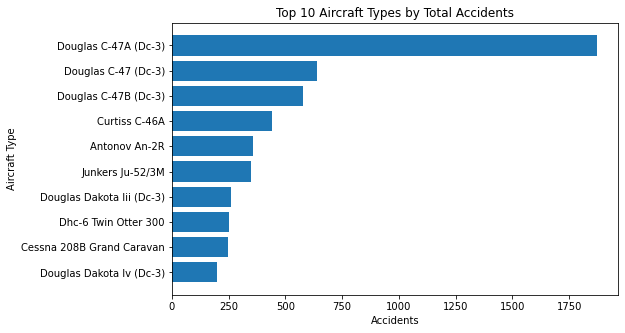

In [234]:
# Horizontal bar chart (highest at top)
plt.figure(figsize=(8,5))
plt.barh(by_type['type'][::-1].astype(str), by_type['accidents'][::-1])
plt.title('Top 10 Aircraft Types by Total Accidents')
plt.xlabel('Accidents')
plt.ylabel('Aircraft Type')
plt.show()

In [235]:
##7.1.2 Top 10 Aircraft Types by Fatal Accidents 
#This shows the aircraft types that have been involved in the highest number of fatal accidents, helping us compare frequency with severity.
by_type_fatal = (
    df_clean[df_clean['is_fatal'] == 1]   # keep only fatal accidents
      .groupby('type')
      .size()
      .reset_index(name='fatal_accidents')
      .sort_values('fatal_accidents', ascending=False)
      .head(10)
)

In [236]:
# quick table view
by_type_fatal

,type,fatal_accidents
903,Douglas C-47A (Dc-3),1489
900,Douglas C-47 (Dc-3),518
904,Douglas C-47B (Dc-3),432
758,Curtiss C-46A,338
1402,Junkers Ju-52/3M,298
956,Douglas Dakota Iii (Dc-3),203
89,Antonov An-2R,169
699,Consolidated Pby-5A Catalina,153
698,Consolidated Pby-5 Catalina,144
759,Curtiss C-46D,139


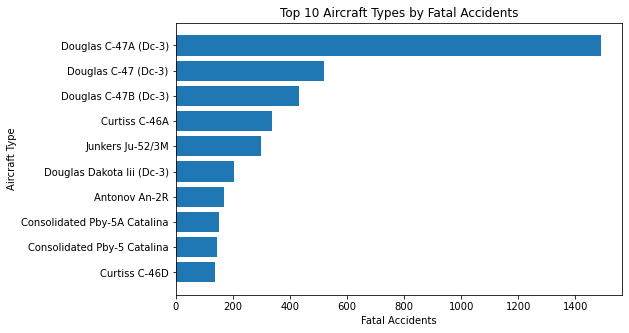

In [237]:
# Horizontal bar chart
plt.figure(figsize=(8,5))
plt.barh(by_type_fatal['type'][::-1].astype(str), by_type_fatal['fatal_accidents'][::-1])
plt.title('Top 10 Aircraft Types by Fatal Accidents')
plt.xlabel('Fatal Accidents')
plt.ylabel('Aircraft Type')
plt.show()

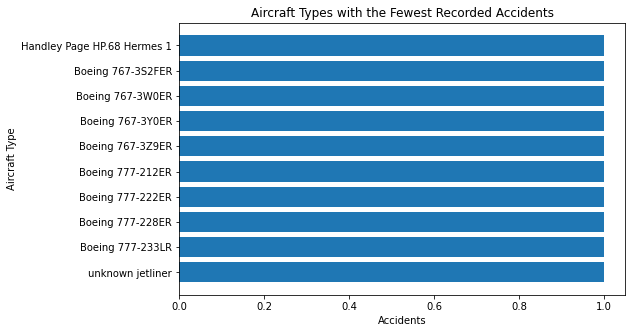

,type,accidents
3176,unknown jetliner,1
1070,Boeing 777-233LR,1
1069,Boeing 777-228ER,1
1068,Boeing 777-222ER,1
1067,Boeing 777-212ER,1
1066,Boeing 767-3Z9ER,1
1065,Boeing 767-3Y0ER,1
1064,Boeing 767-3W0ER,1
1063,Boeing 767-3S2FER,1
2260,Handley Page HP.68 Hermes 1,1


In [238]:
##7.1.3 Aircraft Types with Fewest Accidents
#This shows aircraft types with the lowest accident counts, highlighting models that may be safer.
low_accidents = (
    df.groupby('type')
      .size()
      .reset_index(name='accidents')
      .sort_values('accidents', ascending=True)
      .head(10)
)
# plot
plt.figure(figsize=(8,5))
plt.barh(low_accidents['type'].astype(str), low_accidents['accidents'])
plt.title('Aircraft Types with the Fewest Recorded Accidents')
plt.xlabel('Accidents')
plt.ylabel('Aircraft Type')
plt.show()

# quick table
low_accidents


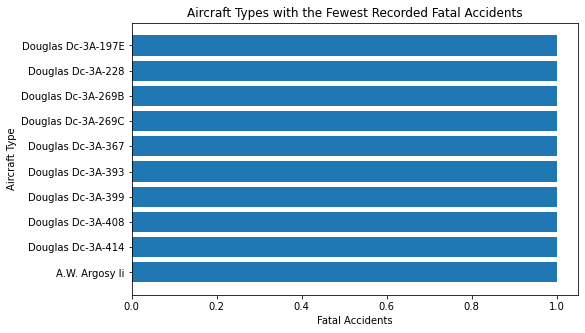

,type,fatal_accidents
0,A.W. Argosy Ii,1
1048,Douglas Dc-3A-414,1
1047,Douglas Dc-3A-408,1
1046,Douglas Dc-3A-399,1
1045,Douglas Dc-3A-393,1
1044,Douglas Dc-3A-367,1
1043,Douglas Dc-3A-269C,1
1042,Douglas Dc-3A-269B,1
1037,Douglas Dc-3A-228,1
1036,Douglas Dc-3A-197E,1


In [239]:
## 7.1.4 Aircraft Types with Fewest Fatal Accidents
#This chart highlights aircraft types that have the lowest number of fatal accidents, which may indicate safer operational histories or lower exposure in accident records.
# Bottom 10 aircraft types by fatal accidents (ignoring those with zero to keep it meaningful)
low_fatal = (
    df_clean[df_clean['is_fatal'] == 1]
      .groupby('type')
      .size()
      .reset_index(name='fatal_accidents')
      .sort_values('fatal_accidents', ascending=True)
      .head(10)
)

# plot
plt.figure(figsize=(8,5))
plt.barh(low_fatal['type'].astype(str), low_fatal['fatal_accidents'])
plt.title('Aircraft Types with the Fewest Recorded Fatal Accidents')
plt.xlabel('Fatal Accidents')
plt.ylabel('Aircraft Type')
plt.show()

# quick table
low_fatal


*Analysis and Insight*

The results indicate that the Douglas C-47 series has the highest accident counts overall, with the C-47A recording 1,873 accidents and 1,489 fatal cases. Other types such as the Curtiss C-46A and Junkers Ju-52/3M also feature prominently in both total and fatal accidents. In contrast, some aircraft types, including Boeing 767 and 777 variants, as well as several Douglas DC-3A sub-models, appear only once in the dataset for either total or fatal accidents. Overall, the findings highlight that certain aircraft types are consistently linked to higher accident and fatality records, while others appear rarely in the dataset.

**7.2 What are the accident trends over time?**

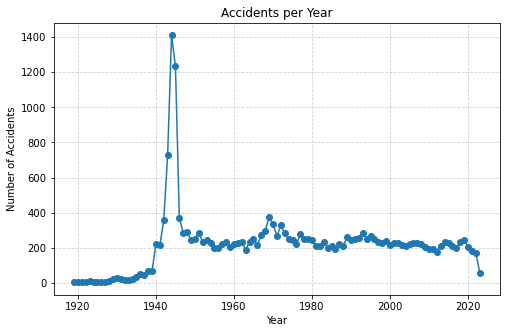

In [240]:
##7.2.1 Accidents per Year
#This chart shows the number of accidents recorded each year, helping us understand overall safety trends over time.
accidents_per_year = (
    df_clean.groupby('year')
      .size()
      .reset_index(name='accidents')
      .sort_values('year')
)

# Line chart
plt.figure(figsize=(8,5))
plt.plot(accidents_per_year['year'], accidents_per_year['accidents'], marker='o')
plt.title('Accidents per Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



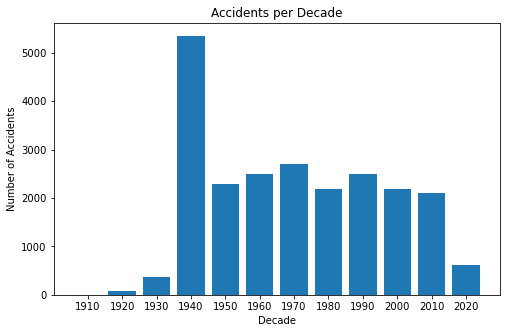

,decade,accidents
0,1910,2
1,1920,70
2,1930,369
3,1940,5350
4,1950,2283
5,1960,2505
6,1970,2701
7,1980,2190
8,1990,2505
9,2000,2190


In [241]:
## 7.2.2 Grouping accidents by decade
accidents_per_decade = (
    df_clean.groupby('decade')
      .size()
      .reset_index(name='accidents')
      .sort_values('decade')
)

# Bar chart
plt.figure(figsize=(8,5))
plt.bar(accidents_per_decade['decade'].astype(str), accidents_per_decade['accidents'])
plt.title('Accidents per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Accidents')
plt.show()

# Quick table
accidents_per_decade


*Analysis and Insight*

The yearly and decade-level trends indicate that aviation accidents rose sharply during the 1940s, reaching their peak before declining significantly in the 1950s. This sharp drop suggests major improvements in aviation practices and safety oversight after the war period. From the 1960s onwards, accidents remained relatively stable over several decades, reflecting a period of consistency in safety performance. More recently, the 2020s show a notable decline, which may point to further advances in safety management and regulatory enforcement. Overall, the trend highlights long-term progress in aviation safety, despite fluctuations in specific periods.

**7.3 Which operators and countries account for the most accidents?**

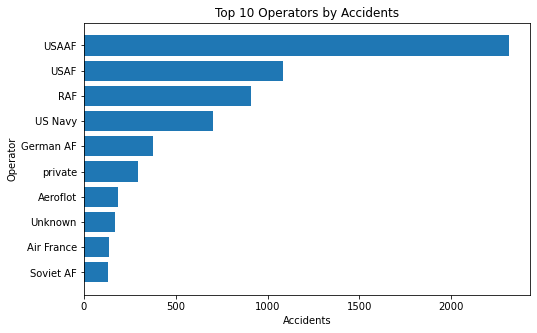

,operator,accidents
5540,USAAF,2316
5546,USAF,1082
4286,RAF,911
5533,US Navy,701
2481,German AF,378
5946,private,296
259,Aeroflot,188
5626,Unknown,169
545,Air France,138
4928,Soviet AF,130


In [249]:
##7.3.1 Top 10 operators by total accidents
top_operators = (
    df_clean.groupby('operator')
      .size()
      .reset_index(name='accidents')
      .sort_values('accidents', ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(8,5))
plt.barh(top_operators['operator'][::-1], top_operators['accidents'][::-1])
plt.title('Top 10 Operators by Accidents')
plt.xlabel('Accidents')
plt.ylabel('Operator')
plt.show()

# Quick table
top_operators


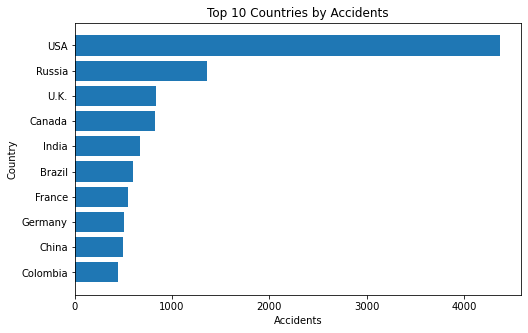

,country,accidents
219,USA,4370
171,Russia,1357
216,U.K.,834
38,Canada,824
96,India,666
31,Brazil,602
74,France,547
80,Germany,502
44,China,498
47,Colombia,447


In [247]:
##7.3.2 Top 10 Countries by Accidents
#This chart highlights the countries with the highest number of accidents recorded in the dataset.
top_countries = (
    df_clean.groupby('country')
      .size()
      .reset_index(name='accidents')
      .sort_values('accidents', ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(8,5))
plt.barh(top_countries['country'][::-1], top_countries['accidents'][::-1])
plt.title('Top 10 Countries by Accidents')
plt.xlabel('Accidents')
plt.ylabel('Country')
plt.show()

# Quick table
top_countries


*Analysis and Insight*

The operator results show that military organizations dominate accident records, with the USAAF (2,316), USAF (1,082), and RAF (911) accounting for the largest numbers, followed by the US Navy (701) and German Air Force (378). Civilian operators such as Aeroflot (188) and Air France (138) are also represented, alongside private operators with 296 accidents. The Soviet Air Force appears with 130 accidents, reflecting its historical presence in accident records. Looking at countries, the USA leads with 4,370 recorded accidents, far ahead of Russia (1,357) and the U.K. (834). Canada, India, Brazil, France, Germany, China, and Colombia also rank among the top 10. Together, these findings highlight that aviation accidents are concentrated in countries with extensive aviation activity and that military operators account for a particularly large share of recorded accidents compared to commercial and private entities.